In [6]:
# %% [markdown]
# # lab6: 회로를 '학습'시키기 — 변분 회로와 VQE
# ### 양자 머신러닝 실습 (PennyLane · Colab)
#
# 지금까지는 고정된 회로를 실행만 했다. 이제 회로에 **조절 가능한 파라미터**를 두고,
# 원하는 목표(비용함수)를 최소화하도록 파라미터를 **학습**시킨다.
# 이것이 변분 양자 회로(VQC)와 VQE의 핵심이며, 모든 양자 머신러닝의 엔진이다.
#
# **학습 목표**
# 1. 파라미터가 있는 회로(변분 회로)와 비용함수의 개념.
# 2. 경사하강법으로 비용 <Z> = cos(θ) 를 최소화 (VQE 축소판).
# 3. 최적화가 θ → π (비용 → -1, 바닥상태)로 수렴하는 과정 관찰.
# 4. (보너스) 최적화 동안 큐빗 상태가 Bloch 구에서 어떻게 움직이는지 시각화.
#
# (그림 라벨은 영어, 코드 주석/출력은 한글)

# %%
# 설치 — Colab에서 최초 1회만: 아래 줄의 주석을 해제해 실행
!pip install -q pennylane


In [7]:

import pennylane as qml
from pennylane import numpy as np
import numpy as std_np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: Bloch 구 3D
import warnings
warnings.filterwarnings("ignore")

SEED = 1234
dev = qml.device("default.qubit", wires=1)



In [8]:

# %%
# ===========================================================
#  6-1: VQE — 비용함수 <Z> = cos(θ) 최소화
# ===========================================================
print("=" * 60)
print("lab6-1: 변분 회로 최적화 (VQE 축소판)")
print("=" * 60)


@qml.qnode(dev)
def cost(params):
    qml.RX(params[0], wires=0)          # 조절 파라미터 theta
    return qml.expval(qml.PauliZ(0))    # 비용 = <Z> = cos(theta)  (최소 -1)


@qml.qnode(dev)
def bloch_vector(t):
    qml.RX(t, wires=0)
    return (qml.expval(qml.PauliX(0)),
            qml.expval(qml.PauliY(0)),
            qml.expval(qml.PauliZ(0)))   # Bloch 좌표 (<X>,<Y>,<Z>)



lab6-1: 변분 회로 최적화 (VQE 축소판)


In [9]:

opt = qml.GradientDescentOptimizer(stepsize=0.4)
params = np.array([0.5], requires_grad=True)   # 초기 theta = 0.5

history = []       # 비용 기록
trajectory = []    # Bloch 궤적 기록
for step in range(50):
    t = float(params[0])
    trajectory.append(tuple(float(v) for v in bloch_vector(t)))
    params = opt.step(cost, params)
    c = float(cost(params))
    history.append(c)
    if step % 10 == 0:
        print(f"  step {step:3d}:  theta={float(params[0]):.4f},  <Z>={c:+.5f}")

print(f"\n최종:  theta={float(params[0]):.4f}  (이론 π={float(np.pi):.4f}),  <Z>={history[-1]:+.5f}")
print("  => 최적화가 파라미터를 조절해 비용을 최소값 -1 로 끌어내렸다.")


  step   0:  theta=0.6918,  <Z>=+0.77012
  step  10:  theta=3.0788,  <Z>=-0.99803
  step  20:  theta=3.1412,  <Z>=-1.00000
  step  30:  theta=3.1416,  <Z>=-1.00000
  step  40:  theta=3.1416,  <Z>=-1.00000

최종:  theta=3.1416  (이론 π=3.1416),  <Z>=-1.00000
  => 최적화가 파라미터를 조절해 비용을 최소값 -1 로 끌어내렸다.


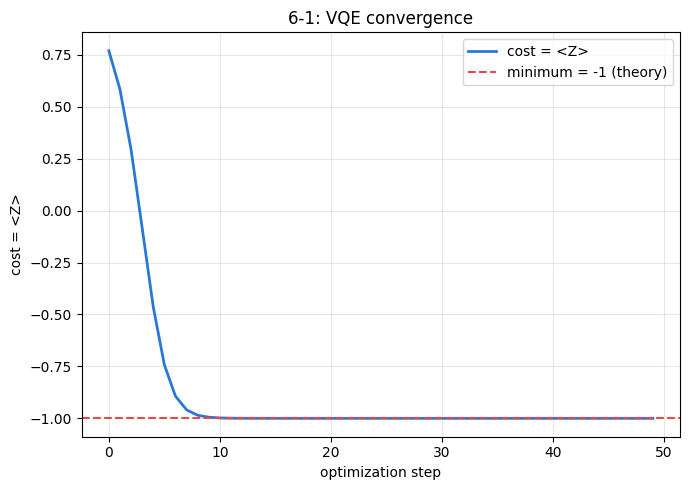

In [10]:

# 수렴 곡선
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(history, "-", color="#2a78d6", lw=2, label="cost = <Z>")
ax.axhline(-1, color="#e34948", ls="--", lw=1.5, label="minimum = -1 (theory)")
ax.set_xlabel("optimization step")
ax.set_ylabel("cost = <Z>")
ax.set_title("6-1: VQE convergence")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()




lab6-2: Bloch 구 위의 최적화 궤적
  RX 최적화는 상태를 북극(|0>) 에서 남극(|1>, 바닥상태) 으로 끌고 간다.


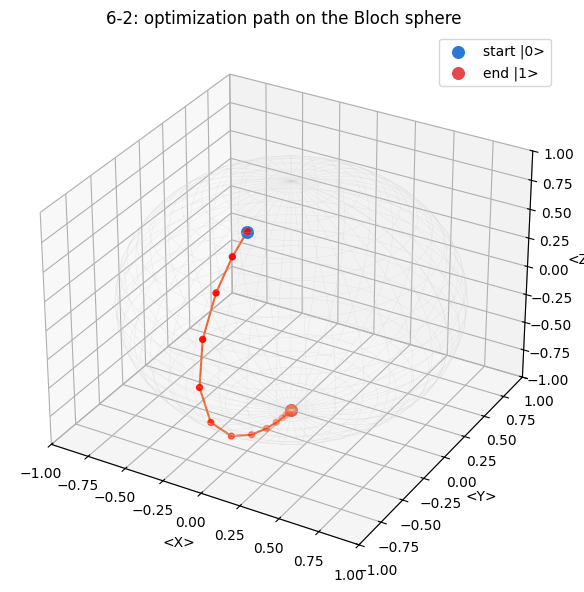


핵심: 회로 학습 = 상태(또는 파라미터)를 목표 방향으로 조금씩 이동시키는 것.
      이 단순한 원리가 그대로 확장되어 양자 분류기·양자 커널 학습이 된다.


In [11]:

# %%
# ===========================================================
#  6-2: (보너스) 최적화 궤적을 Bloch 구에서 보기
# ===========================================================
print("\n" + "=" * 60)
print("lab6-2: Bloch 구 위의 최적화 궤적")
print("=" * 60)
print("  RX 최적화는 상태를 북극(|0>) 에서 남극(|1>, 바닥상태) 으로 끌고 간다.")

tx = [p[0] for p in trajectory]
ty = [p[1] for p in trajectory]
tz = [p[2] for p in trajectory]

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

# 투명한 Bloch 구
u = std_np.linspace(0, 2 * std_np.pi, 40)
v = std_np.linspace(0, std_np.pi, 25)
xs = std_np.outer(std_np.cos(u), std_np.sin(v))
ys = std_np.outer(std_np.sin(u), std_np.sin(v))
zs = std_np.outer(std_np.ones_like(u), std_np.cos(v))
ax.plot_wireframe(xs, ys, zs, color="lightgray", lw=0.3, alpha=0.5)

# 궤적 (색이 진해질수록 나중 단계)
ax.plot(tx, ty, tz, "-", color="#eb6834", lw=1.5)
ax.scatter(tx, ty, tz, c=range(len(tx)), cmap="autumn", s=18)
ax.scatter([tx[0]], [ty[0]], [tz[0]], color="#2a78d6", s=70, label="start |0>")
ax.scatter([tx[-1]], [ty[-1]], [tz[-1]], color="#e34948", s=70, label="end |1>")

ax.set_xlabel("<X>"); ax.set_ylabel("<Y>"); ax.set_zlabel("<Z>")
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
ax.set_title("6-2: optimization path on the Bloch sphere")
ax.legend()
plt.tight_layout()
plt.show()

print("\n핵심: 회로 학습 = 상태(또는 파라미터)를 목표 방향으로 조금씩 이동시키는 것.")
print("      이 단순한 원리가 그대로 확장되어 양자 분류기·양자 커널 학습이 된다.")